# 05 - Model Evaluation

This notebook evaluates the trained AutoGluon models and summarises results from the Azure ML experiments.

**Sections 1–4** (backbone comparison, CV summary, training times) run entirely from the downloaded Azure ML result CSVs in `../results/` — no model files needed.

**Sections 5–7** (predicted vs actual, residuals, total biomass) load a trained model from `../models/` and run inference on the held-out validation set. By default this uses the local smoke-test model (120 s training). To use the Azure-trained model instead, download the four `autogluon_<target>/` folders from the best Azure ML job and update `MODEL_DIR`.

## Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

TARGETS     = ["Dry_Clover_g", "Dry_Dead_g", "Dry_Green_g", "GDM_g"]
RANDOM_SEED = 42
VAL_SIZE    = 0.2
RESULTS_DIR = Path("../results")
MODEL_DIR   = Path("../models")  # update to Azure ML outputs folder if downloaded

## 1. Backbone comparison

Three backbone architectures were compared on the same 80/20 train/val split:
- **Default** — AutoGluon's built-in default image encoder
- **Swin-Base** — `swin_base_patch4_window7_224`, a hierarchical vision transformer
- **EfficientNet-B4** — `efficientnet_b4`, an efficient CNN

All metrics are on the original grams scale (targets were log1p-transformed during training and reversed with expm1 at evaluation).

In [2]:
backbone_files = {
    "Default"        : RESULTS_DIR / "default_results_20260409_025518.csv",
    "Swin-Base"      : RESULTS_DIR / "swinbase-results_20260409_034653.csv",
    "EfficientNet-B4": RESULTS_DIR / "efficientnetb4-results_20260409_043912.csv",
}

# Build a tidy DataFrame of all results
rows = []
for backbone, path in backbone_files.items():
    df = pd.read_csv(path, index_col=0)
    for target in TARGETS:
        rows.append({
            "Backbone": backbone,
            "Target"  : target,
            "RMSE"    : df.loc[target, "RMSE"],
            "R2"      : df.loc[target, "R2"],
        })

comp_df = pd.DataFrame(rows)

# R² pivot
r2_pivot = comp_df.pivot(index="Target", columns="Backbone", values="R2").round(4)
print("--- R² by backbone ---")
print(r2_pivot.to_string())

# RMSE pivot
rmse_pivot = comp_df.pivot(index="Target", columns="Backbone", values="RMSE").round(2)
print("\n--- RMSE (g) by backbone ---")
print(rmse_pivot.to_string())

--- R² by backbone ---
Backbone      Default  EfficientNet-B4  Swin-Base
Target                                           
Dry_Clover_g   0.5632           0.6074     0.6291
Dry_Dead_g     0.2800           0.1943     0.4293
Dry_Green_g    0.7260           0.6141     0.6262
GDM_g          0.8252           0.5156     0.8077

--- RMSE (g) by backbone ---
Backbone      Default  EfficientNet-B4  Swin-Base
Target                                           
Dry_Clover_g     8.82             8.36       8.13
Dry_Dead_g      10.21            10.80       9.09
Dry_Green_g     11.35            13.47      13.26
GDM_g            9.17            15.26       9.62


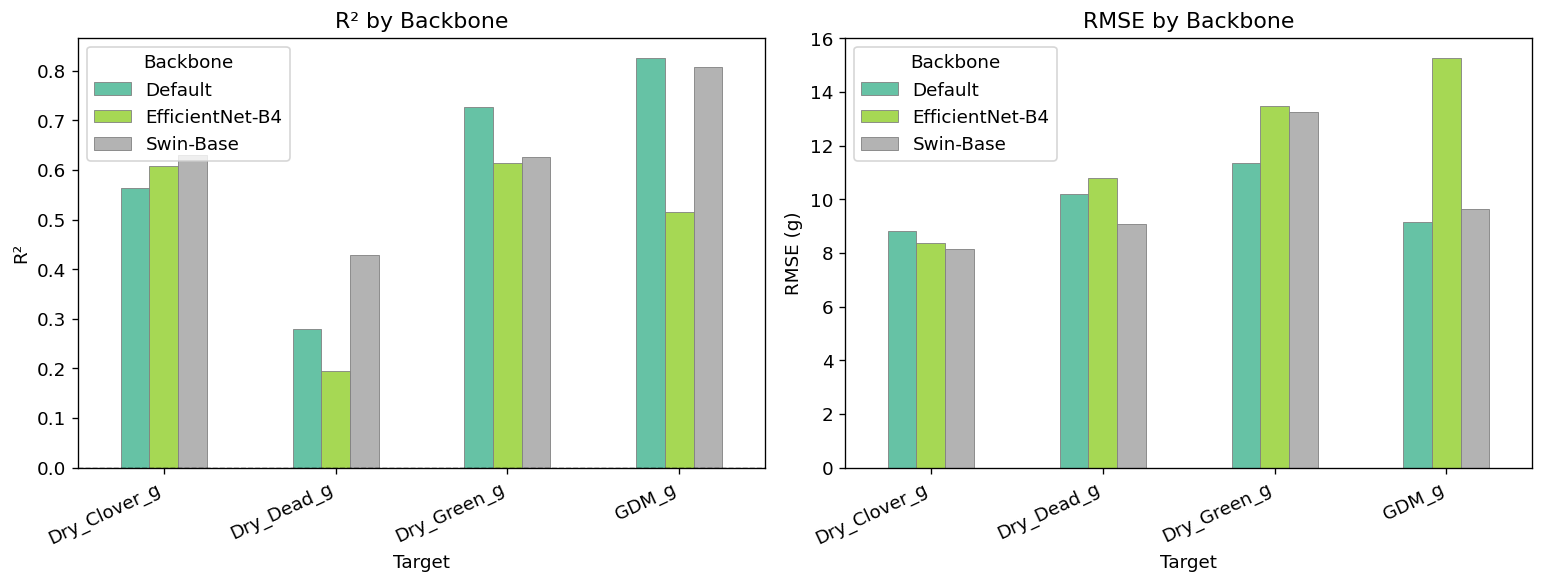

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

r2_pivot.plot(kind="bar", ax=axes[0], colormap="Set2", edgecolor="grey", linewidth=0.5)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("R²")
axes[0].set_title("R² by Backbone")
axes[0].set_xticklabels(TARGETS, rotation=25, ha="right")
axes[0].legend(title="Backbone")

rmse_pivot.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="grey", linewidth=0.5)
axes[1].set_ylabel("RMSE (g)")
axes[1].set_title("RMSE by Backbone")
axes[1].set_xticklabels(TARGETS, rotation=25, ha="right")
axes[1].legend(title="Backbone")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "backbone_comparison.png", bbox_inches="tight")
plt.show()

## 2. Cross-validation results

5-fold cross-validation was run with the default backbone to get more reliable performance estimates. With only 357 samples, a single 80/20 split is sensitive to which samples land in the held-out set. The mean and std across folds give a more honest picture of generalisation performance.

In [4]:
cv_df = pd.read_csv(RESULTS_DIR / "cv_results_20260409_051116.csv", index_col=0)
print("--- 5-Fold CV Results (default backbone) ---")
print(cv_df.round(4).to_string())

--- 5-Fold CV Results (default backbone) ---
              RMSE_mean  RMSE_std  R2_mean  R2_std
Dry_Clover_g     8.7388    1.3238   0.4566  0.0261
Dry_Dead_g      10.3753    0.9065   0.2852  0.0803
Dry_Green_g     13.8560    2.4601   0.6953  0.0586
GDM_g           12.9231    1.4567   0.7257  0.0360


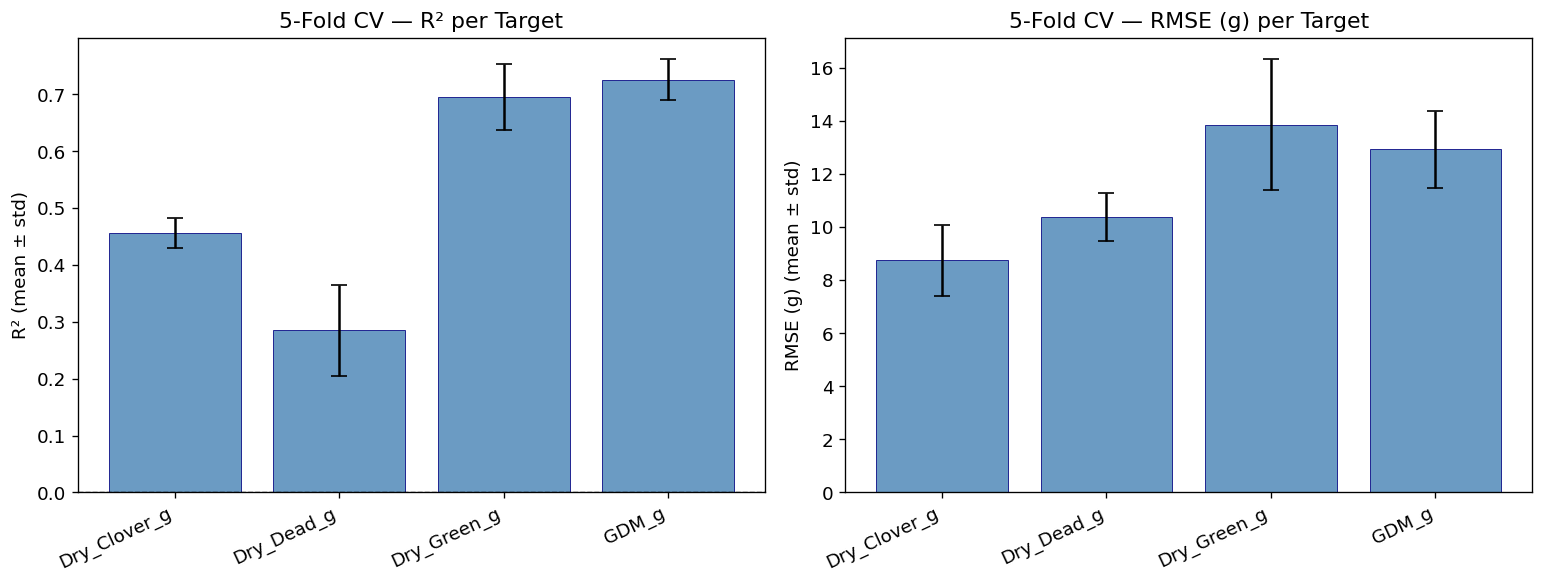

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, label in [
    (axes[0], "R2",   "R²"),
    (axes[1], "RMSE", "RMSE (g)"),
]:
    means = cv_df[f"{metric}_mean"]
    stds  = cv_df[f"{metric}_std"]
    x     = range(len(TARGETS))

    ax.bar(x, means, yerr=stds, capsize=5, color="steelblue",
           edgecolor="navy", linewidth=0.6, alpha=0.8)
    if metric == "R2":
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(list(x))
    ax.set_xticklabels(TARGETS, rotation=25, ha="right")
    ax.set_ylabel(f"{label} (mean ± std)")
    ax.set_title(f"5-Fold CV — {label} per Target")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cv_results.png", bbox_inches="tight")
plt.show()

## 3. Training time summary

Training times per target from the default backbone run (Tesla T4 GPU).

In [6]:
import json

fit_files = {
    "Default"        : RESULTS_DIR / "default_fit_summary_20260409_025518.json",
    "Swin-Base"      : RESULTS_DIR / "swinbase-fit_summary_20260409_034653.json",
    "EfficientNet-B4": RESULTS_DIR / "efficientnetb4-fit_summary_20260409_043912.json",
}

time_rows = []
for backbone, path in fit_files.items():
    with open(path) as f:
        summary = json.load(f)
    for target in TARGETS:
        t = summary[target]["training_time"]
        time_rows.append({"Backbone": backbone, "Target": target,
                           "Training time (min)": round(t / 60, 1)})

time_df = pd.DataFrame(time_rows)
pivot   = time_df.pivot(index="Target", columns="Backbone", values="Training time (min)")
print(pivot.to_string())

Backbone      Default  EfficientNet-B4  Swin-Base
Target                                           
Dry_Clover_g     10.8              5.7        9.8
Dry_Dead_g       10.3              8.6       12.9
Dry_Green_g      11.3              8.5       13.1
GDM_g            14.2              4.7       12.0


## 4. Best results summary

Single-split results from the best-performing backbone per target, alongside the 5-fold CV mean (which is the more reliable estimate).

In [7]:
summary_rows = []
for target in TARGETS:
    # Best single-split R² across all backbones
    best_r2       = comp_df[comp_df["Target"] == target].sort_values("R2", ascending=False).iloc[0]
    cv_r2_mean    = cv_df.loc[target, "R2_mean"]
    cv_r2_std     = cv_df.loc[target, "R2_std"]
    summary_rows.append({
        "Target"              : target,
        "Best backbone"       : best_r2["Backbone"],
        "Best R² (single split)": round(best_r2["R2"], 4),
        "CV R² mean ± std"   : f"{cv_r2_mean:.3f} ± {cv_r2_std:.3f}",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Target")
print(summary_df.to_string())

             Best backbone  Best R² (single split) CV R² mean ± std
Target                                                             
Dry_Clover_g     Swin-Base                  0.6291    0.457 ± 0.026
Dry_Dead_g       Swin-Base                  0.4293    0.285 ± 0.080
Dry_Green_g        Default                  0.7260    0.695 ± 0.059
GDM_g              Default                  0.8252    0.726 ± 0.036


---
## 5–7. Predicted vs actual (requires trained model)

The cells below load a trained model and generate predictions on the validation set. By default they use the **local smoke-test model** from `03_modelling.ipynb` (120 s training — weak results, useful only for pipeline validation).

To use the Azure-trained model:
1. Download the four `autogluon_<target>/` folders from the best Azure ML job outputs
2. Place them somewhere locally (e.g. `../models/azure_default/`)
3. Update `MODEL_DIR` in the imports cell to that path

In [8]:
from autogluon.multimodal import MultiModalPredictor

DATA_PATH = Path("../data/processed/df_model.csv")
df        = pd.read_csv(DATA_PATH)

raw_dir          = DATA_PATH.parent.parent / "raw"
df["image_path"] = df["image_path"].apply(lambda x: str(raw_dir / x))

df_train, df_val = train_test_split(df, test_size=VAL_SIZE, random_state=RANDOM_SEED)
df_val_orig      = df_val.copy()

df_val_log = df_val.copy()
for t in TARGETS:
    df_val_log[t] = np.log1p(df_val_log[t])

print(f"Val set: {len(df_val)} samples")

c:\Users\Kurtis\Documents\Data Analysis\Projects\image2biomass\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Val set: 72 samples


In [9]:
predictors = {}
for target in TARGETS:
    model_path = MODEL_DIR / f"autogluon_{target}"
    if not model_path.exists():
        raise FileNotFoundError(
            f"No model at {model_path}.\n"
            "Either run 03_modelling.ipynb first, or download Azure ML model outputs "
            "and update MODEL_DIR."
        )
    predictors[target] = MultiModalPredictor.load(str(model_path))
    print(f"Loaded: {target}")

y_true_all = {t: df_val_orig[t].values for t in TARGETS}
y_pred_all = {
    t: np.clip(np.expm1(predictors[t].predict(df_val_log).values), 0, None)
    for t in TARGETS
}

Load pretrained checkpoint: c:\Users\Kurtis\Documents\Data Analysis\Projects\image2biomass\models\autogluon_Dry_Clover_g\model.ckpt


Loaded: Dry_Clover_g


Load pretrained checkpoint: c:\Users\Kurtis\Documents\Data Analysis\Projects\image2biomass\models\autogluon_Dry_Dead_g\model.ckpt


Loaded: Dry_Dead_g


Load pretrained checkpoint: c:\Users\Kurtis\Documents\Data Analysis\Projects\image2biomass\models\autogluon_Dry_Green_g\model.ckpt


...

Predicting DataLoader 0: 100%|██████████| 3/3 [01:05<00:00,  0.05it/s]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Predicting DataLoader 0: 100%|██████████| 3/3 [01:11<00:00,  0.04it/s]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Predicting DataLoader 0: 100%|██████████| 3/3 [00:50<00:00,  0.06it/s]


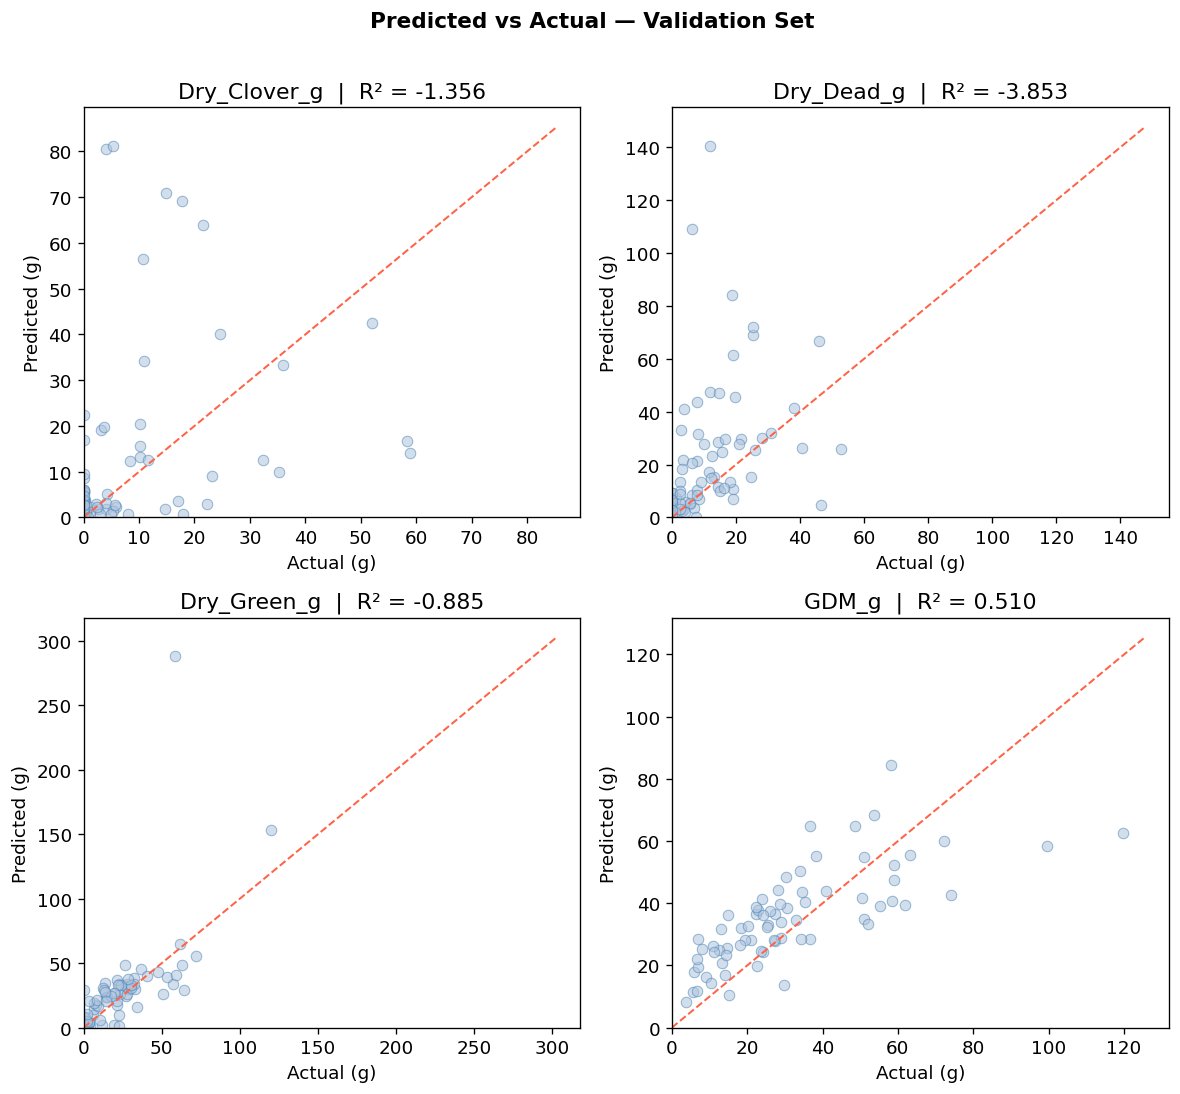

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

for i, target in enumerate(TARGETS):
    ax     = axes[i]
    y_true = y_true_all[target]
    y_pred = y_pred_all[target]
    r2     = r2_score(y_true, y_pred)

    ax.scatter(y_true, y_pred, alpha=0.55, edgecolors="steelblue",
               facecolors="lightsteelblue", linewidths=0.6, s=40)
    lim = max(y_true.max(), y_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], "--", color="tomato", linewidth=1.2)
    ax.set_xlabel("Actual (g)")
    ax.set_ylabel("Predicted (g)")
    ax.set_title(f"{target}  |  R² = {r2:.3f}")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

fig.suptitle("Predicted vs Actual — Validation Set", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pred_vs_actual.png", bbox_inches="tight")
plt.show()

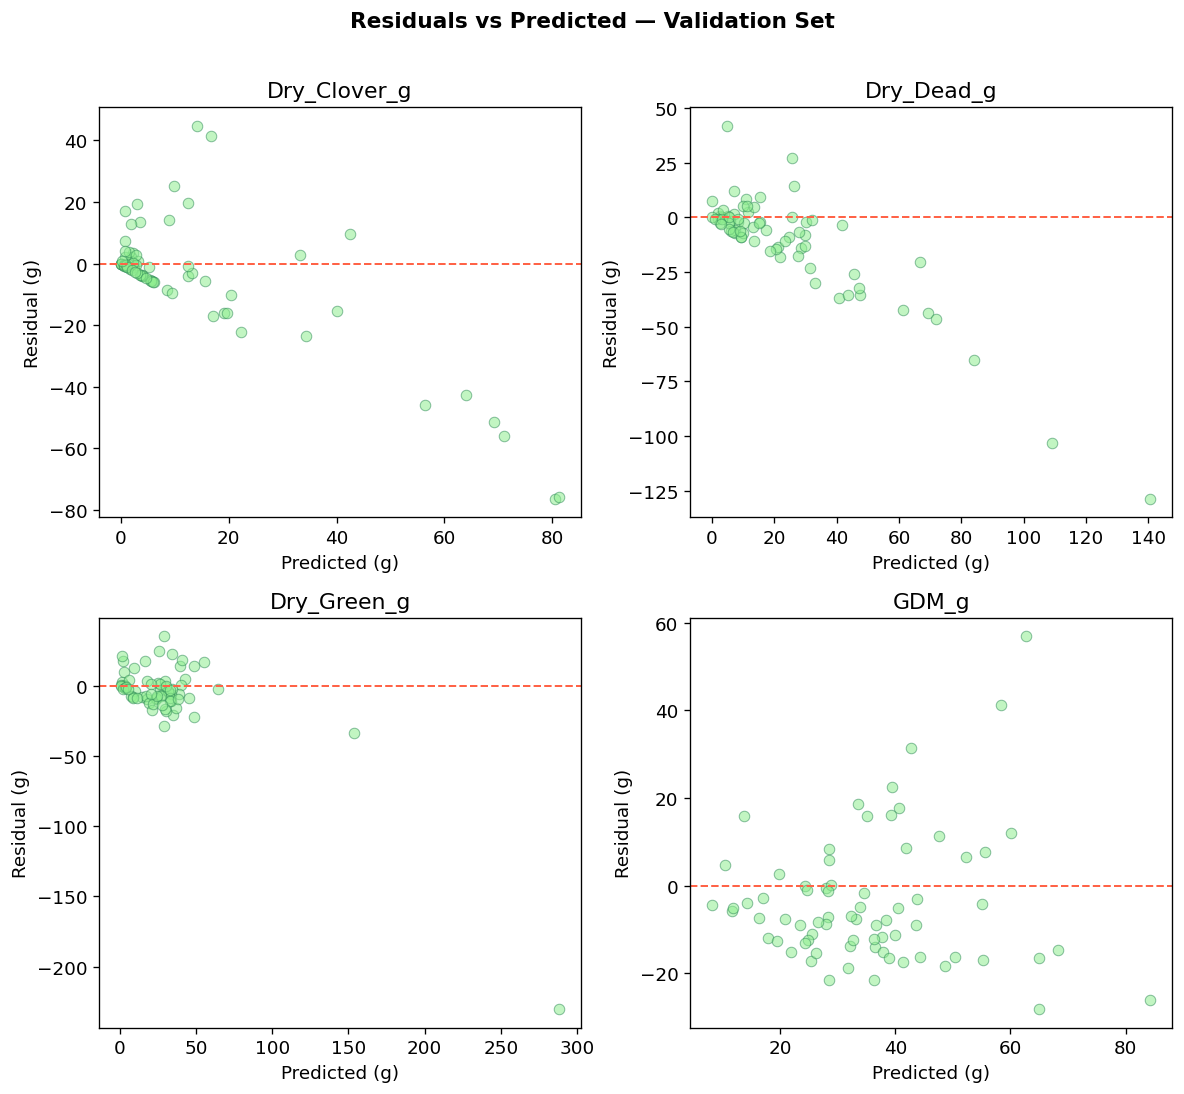

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

for i, target in enumerate(TARGETS):
    ax        = axes[i]
    residuals = y_true_all[target] - y_pred_all[target]
    ax.scatter(y_pred_all[target], residuals, alpha=0.55, edgecolors="seagreen",
               facecolors="lightgreen", linewidths=0.6, s=40)
    ax.axhline(0, color="tomato", linewidth=1.2, linestyle="--")
    ax.set_xlabel("Predicted (g)")
    ax.set_ylabel("Residual (g)")
    ax.set_title(target)

fig.suptitle("Residuals vs Predicted — Validation Set", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "residuals.png", bbox_inches="tight")
plt.show()

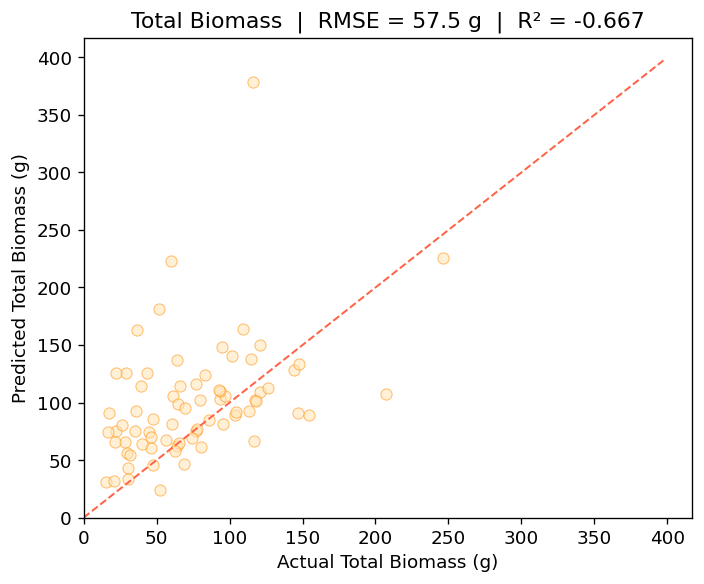

Total biomass RMSE : 57.48 g
Total biomass R²   : -0.6673


In [12]:
total_true = sum(y_true_all[t] for t in TARGETS)
total_pred = sum(y_pred_all[t] for t in TARGETS)
total_rmse = np.sqrt(mean_squared_error(total_true, total_pred))
total_r2   = r2_score(total_true, total_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(total_true, total_pred, alpha=0.55, edgecolors="darkorange",
           facecolors="moccasin", linewidths=0.6, s=45)
lim = max(total_true.max(), total_pred.max()) * 1.05
ax.plot([0, lim], [0, lim], "--", color="tomato", linewidth=1.2)
ax.set_xlabel("Actual Total Biomass (g)")
ax.set_ylabel("Predicted Total Biomass (g)")
ax.set_title(f"Total Biomass  |  RMSE = {total_rmse:.1f} g  |  R² = {total_r2:.3f}")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "total_biomass.png", bbox_inches="tight")
plt.show()

print(f"Total biomass RMSE : {total_rmse:.2f} g")
print(f"Total biomass R²   : {total_r2:.4f}")